# Does Hosting the Olympics Improve Medal Performance?

## Project Inspiration
The Olympic Games are not only the world’s largest sporting event but also a stage where national pride and athletic performance intersect. Whilst watching the Olympics this year, I was struck by how well Japan were doing. As they were the host nation of this Olympics, it got me thinking: Does hosting the Olympics improve performance in the medals table? A recurring observation is that host nations often perform exceptionally well in the medals table. This raises an important question: **Does hosting the Olympics actually improve a country’s medal performance, or is it just a coincidence?**

## Objectives
- **Investigate** historical Olympic data to compare host nations’ performance before, during, and after hosting.  
- **Explore** trends in medal counts using statistical analysis and visualizations.  
- **Evaluate** whether hosting provides a measurable "home advantage" in the overall medals table.  

## Approach
This project focuses on **exploratory data analysis (EDA)** and **statistical testing** using Olympic datasets, including data from the Tokyo Olympics. Visual storytelling will be central, leveraging:
- **Matplotlib & Seaborn** for static plots,  
- **Folium** for interactive geographic mapping.  

The goal is not only to analyze medal performance but also to **encourage deeper exploration** of Olympic data, sparking new questions and insights.  


## Dataset 1: 120 years of Olympic history

This dataset contains detailed information about Olympic athletes, events, and outcomes across multiple Games. Below is an explanation of each column for better understanding:

1. **ID** – Unique identifier for each athlete.  
2. **Name** – Full name of the athlete.  
3. **Sex** – Gender of the athlete (`M` = Male, `F` = Female).  
4. **Age** – Age of the athlete (integer).  
5. **Height** – Athlete’s height in centimeters.  
6. **Weight** – Athlete’s weight in kilograms.  
7. **Team** – Name of the athlete’s team (may represent a nation, region, or combined team).  
8. **NOC** – National Olympic Committee 3-letter code representing the country or region.  
9. **Games** – Year and season of the Olympics (e.g., `2008 Summer`).  
10. **Year** – The year the Olympic Games took place (integer).  
11. **Season** – Whether the Games were `Summer` or `Winter`.  
12. **City** – Host city of the Games.  
13. **Sport** – General category of the sport (e.g., Athletics, Swimming).  
14. **Event** – Specific discipline or event within the sport (e.g., 100m sprint).  
15. **Medal** – Type of medal won (`Gold`, `Silver`, `Bronze`), or `NA` if no medal was awarded.  

Additionally, this dataset can be enriched using a **NOC-to-Region mapping file**, which links each `NOC` code to the corresponding country/region name (e.g., `USA → United States`, `CHN → China`). This helps provide clearer geographic and regional insights during analysis.

# Dataset 2: 2021 Olympics in Tokyo

This dataset provides detailed information about the **Tokyo 2020 Olympics (held in 2021)**, covering athletes, teams, coaches, and events. It serves as a complementary dataset to the historical Olympic records, focusing specifically on the most recent Games.  

## Contents
The dataset is structured into multiple files:  
- **Athletes.xlsx** – Information about over 11,000 athletes, including their names, countries, and disciplines.  
- **Coaches.xlsx** – Details of coaches, including the teams and athletes they supported.  
- **EntriesGender.xlsx** – Participation statistics broken down by gender across events and disciplines.  
- **Medals.xlsx** – Medal counts (Gold, Silver, Bronze) awarded to athletes and teams.  
- **Teams.xlsx** – Details of the 743 teams participating in the Games.  

## Coverage
- **Disciplines**: 47  
- **Teams**: 743  
- **Athletes**: 11,000+   

**Source**: Tokyo Olympics 2020 Website  

## 1) Importing Libraries

In [1]:
import os
os.chdir('C:/Users/phunh.DESKTOP-8S8LTG6/Desktop/Portfolio_projects/Tokyo_olympic')

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)

In [3]:
athlete_events = pd.read_csv('Data/athlete_events.csv')
noc_regions = pd.read_csv('Data/noc_regions.csv')

merged_df = athlete_events.merge(noc_regions, how='left', on='NOC')
merged_df.to_csv('Data/athlete_events_with_regions.csv', index=False)

In [4]:
merged_df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN


## 2) Initial Data Inspections

In [5]:
athlete_df = pd.read_excel('Data/Athletes.xlsx')
coaches_df = pd.read_excel('Data/Coaches.xlsx')
entries_df = pd.read_excel('Data/EntriesGender.xlsx')
medals_df = pd.read_excel('Data/Medals.xlsx')
teams_df = pd.read_excel('Data/Teams.xlsx')

c:\Users\phunh.DESKTOP-8S8LTG6\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\phunh.DESKTOP-8S8LTG6\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
# Create a list of your dataframes with descriptive names
dataframes = {
    'Athletes': athlete_df,
    'Coaches': coaches_df, 
    'Entries by Gender': entries_df,
    'Medals': medals_df,
    'Teams': teams_df,
    'Merged Athlete Events': merged_df
}

In [7]:

for df_name, df in dataframes.items():
    print("=" * 60)
    print(f"DATAFRAME: {df_name.upper()}")
    print("=" * 60)
    
    # Display first 5 rows
    print(f"\n First 5 rows of {df_name}:")
    print("-" * 40)
    print(df.head(5))
    
    # Display descriptive statistics
    print(f"\n Descriptive statistics for {df_name}:")
    print("-" * 40)
    print(df.describe())
    
    # Display dataframe info
    print(f"\n Data types and info for {df_name}:")
    print("-" * 40)
    print(df.info())
    
    print("\n" + "="*60 + "\n")  

DATAFRAME: ATHLETES

 First 5 rows of Athletes:
----------------------------------------
                Name     NOC           Discipline
0    AALERUD Katrine  Norway         Cycling Road
1        ABAD Nestor   Spain  Artistic Gymnastics
2  ABAGNALE Giovanni   Italy               Rowing
3     ABALDE Alberto   Spain           Basketball
4      ABALDE Tamara   Spain           Basketball

 Descriptive statistics for Athletes:
----------------------------------------
             Name                       NOC Discipline
count       11085                     11085      11085
unique      11062                       206         46
top     CHEN Yang  United States of America  Athletics
freq            2                       615       2068

 Data types and info for Athletes:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11085 entries, 0 to 11084
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------

In [8]:
for name, df in dataframes.items():
    print("="*60)
    print(f" Dataset: {name}")
    print("-"*60)
    
    # Shape
    print(f"Shape (rows, cols): {df.shape}")
    
    # Missing values
    print("\nMissing values per column (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    
    # Duplicate rows
    print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
    
    # Cardinality (unique values per column)
    print("\nUnique values per column (top 10):")
    print(df.nunique().sort_values(ascending=False).head(10))
    
    print("\n")

 Dataset: Athletes
------------------------------------------------------------
Shape (rows, cols): (11085, 3)

Missing values per column (top 10):
Name          0
NOC           0
Discipline    0
dtype: int64

Number of duplicate rows: 1

Unique values per column (top 10):
Name          11062
NOC             206
Discipline       46
dtype: int64


 Dataset: Coaches
------------------------------------------------------------
Shape (rows, cols): (394, 4)

Missing values per column (top 10):
Event         145
Name            0
NOC             0
Discipline      0
dtype: int64

Number of duplicate rows: 1

Unique values per column (top 10):
Name          381
NOC            61
Discipline      9
Event           6
dtype: int64


 Dataset: Entries by Gender
------------------------------------------------------------
Shape (rows, cols): (46, 4)

Missing values per column (top 10):
Discipline    0
Female        0
Male          0
Total         0
dtype: int64

Number of duplicate rows: 0

Unique v

## 3) Data Imputation 

In [9]:
merged_df.duplicated().sum()

1385

In [10]:
merged_df[merged_df.duplicated(keep=False)].head(20)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
1251,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN,Belgium,NaN
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN,Belgium,NaN
4281,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4861,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs For Town Planning",NaN,Germany,NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs For Town Planning",NaN,Germany,NaN
4863,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architectural Designs",NaN,Germany,NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architectural Designs",NaN,Germany,NaN
4866,2777,Hermann Reinhard Alker,M,51.0,NaN,NaN,Germany,GER,1936 Summer,1936,Summer,Berlin,Art Competitions,"Art Competitions Mixed Architecture, Unknown Event",NaN,Germany,NaN


In [11]:
merged_df = merged_df.drop_duplicates()

In [12]:
coaches_df = coaches_df.drop_duplicates()
athlete_df = athlete_df.drop_duplicates()

In [13]:
group_means = merged_df.groupby(['region', 'Sex', 'Sport'])[['Height', 'Weight']].transform('mean')

In [14]:
merged_df['Height'] = merged_df['Height'].fillna(group_means['Height'])
merged_df['Weight'] = merged_df['Weight'].fillna(group_means['Weight'])

C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_15456\2940295643.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Height'] = merged_df['Height'].fillna(group_means['Height'])
C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_15456\2940295643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Weight'] = merged_df['Weight'].fillna(group_means['Weight'])


In [15]:
print("Remaining missing values in Height:", merged_df['Height'].isna().sum())
print("Remaining missing values in Weight:", merged_df['Weight'].isna().sum())

Remaining missing values in Height: 2872
Remaining missing values in Weight: 3194


In [16]:
sport_means = merged_df.groupby(['Sex', 'Sport'])[['Height', 'Weight']].transform('mean')
merged_df['Height'] = merged_df['Height'].fillna(sport_means['Height'])
merged_df['Weight'] = merged_df['Weight'].fillna(sport_means['Weight'])

C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_15456\3399610829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Height'] = merged_df['Height'].fillna(sport_means['Height'])
C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_15456\3399610829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Weight'] = merged_df['Weight'].fillna(sport_means['Weight'])


In [17]:
print("Remaining missing values in Height:", merged_df['Height'].isna().sum())
print("Remaining missing values in Weight:", merged_df['Weight'].isna().sum())

Remaining missing values in Height: 100
Remaining missing values in Weight: 451


In [18]:
before_rows = merged_df.shape[0]
merged_df = merged_df.dropna(subset=['Height', 'Weight'])
after_rows = merged_df.shape[0]

print(f"Rows before: {before_rows}")
print(f"Rows after:  {after_rows}")
print(f"Dropped:     {before_rows - after_rows}")

Rows before: 269731
Rows after:  269280
Dropped:     451


In [19]:
merged_df.isna().sum()

ID             0
Name           0
Sex            0
Age         9231
Height         0
Weight         0
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     229674
region       370
notes     264245
dtype: int64

In [20]:
age_means = merged_df.groupby(['region','Sex','Sport'])['Age'].transform('mean')
merged_df['Age'] = merged_df['Age'].fillna(age_means)

In [21]:
merged_df = merged_df.dropna(subset=['Age'])

In [22]:
merged_df = merged_df.drop(columns=['notes'])

In [23]:
# Build a mapping from existing rows
noc_region_map = merged_df.dropna(subset=['region']).drop_duplicates(subset=['NOC'])[['NOC','region']]
noc_region_dict = dict(zip(noc_region_map['NOC'], noc_region_map['region']))

# Fill missing region based on NOC
merged_df['region'] = merged_df.apply(
    lambda r: noc_region_dict.get(r['NOC'], 'Unknown') if pd.isna(r['region']) else r['region'],
    axis=1
)

print("Remaining missing regions:", merged_df['region'].isna().sum())

Remaining missing regions: 0


## 4) Exploratory Data Analysis

### Univariate Analysis

📊 Analysis for: Age
count    269082.000000
mean         25.493627
std           6.113179
min          10.000000
1%           15.000000
5%           18.000000
25%          21.584615
50%          25.000000
75%          28.000000
95%          36.000000
99%          47.000000
max          97.000000
Name: Age, dtype: float64
Skewness: 1.532001468939994
Kurtosis: 5.002584975832056


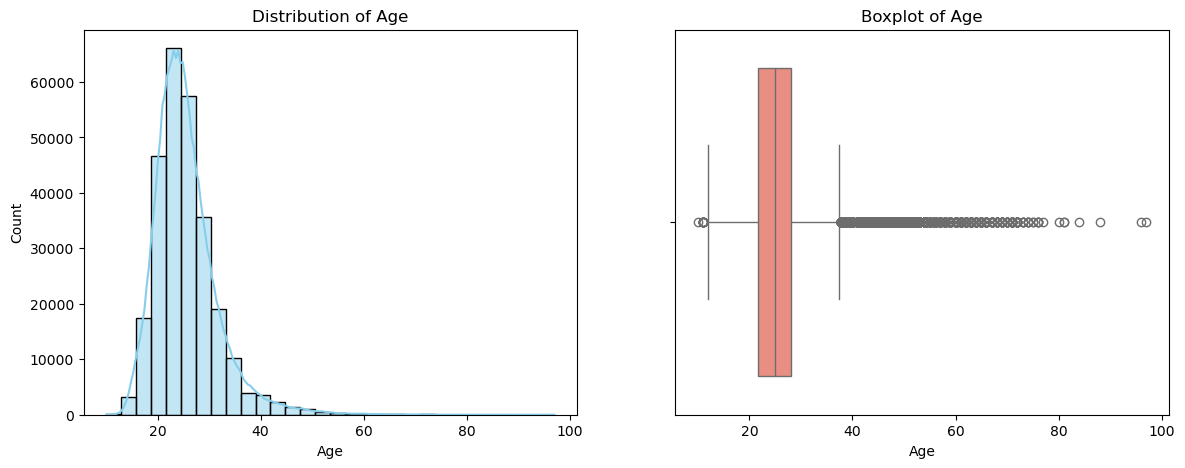

📊 Analysis for: Height
count    269082.000000
mean        175.597312
std           9.916402
min         127.000000
1%          152.000000
5%          159.000000
25%         169.000000
50%         176.000000
75%         182.000000
95%         191.000000
99%         199.000000
max         226.000000
Name: Height, dtype: float64
Skewness: -0.06170566372462566
Kurtosis: 0.38277651541911606


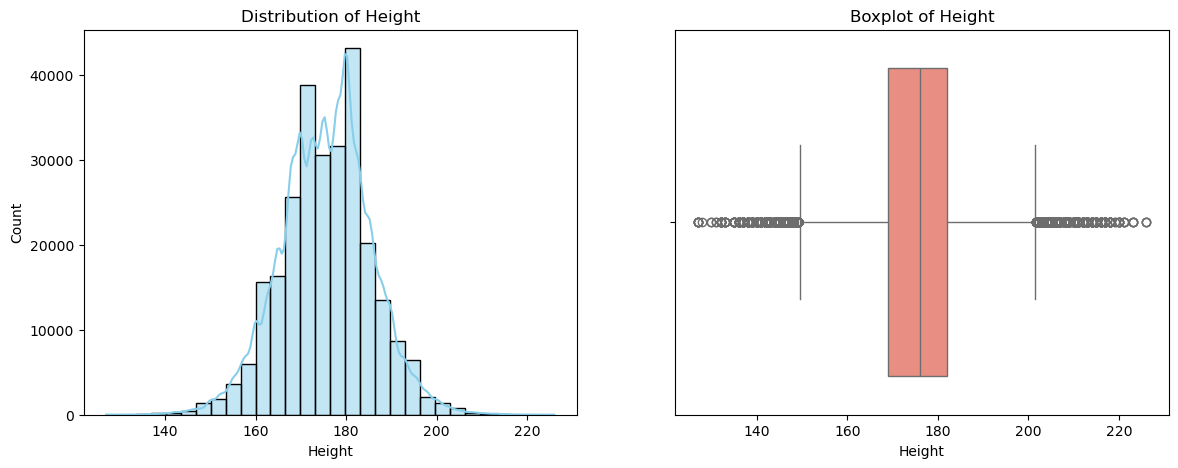

📊 Analysis for: Weight
count    269082.000000
mean         71.248031
std          13.381130
min          25.000000
1%           43.873418
5%           51.000000
25%          62.000000
50%          71.000000
75%          79.000000
95%          93.000000
99%         110.000000
max         214.000000
Name: Weight, dtype: float64
Skewness: 0.6654288261806687
Kurtosis: 2.199672610376324


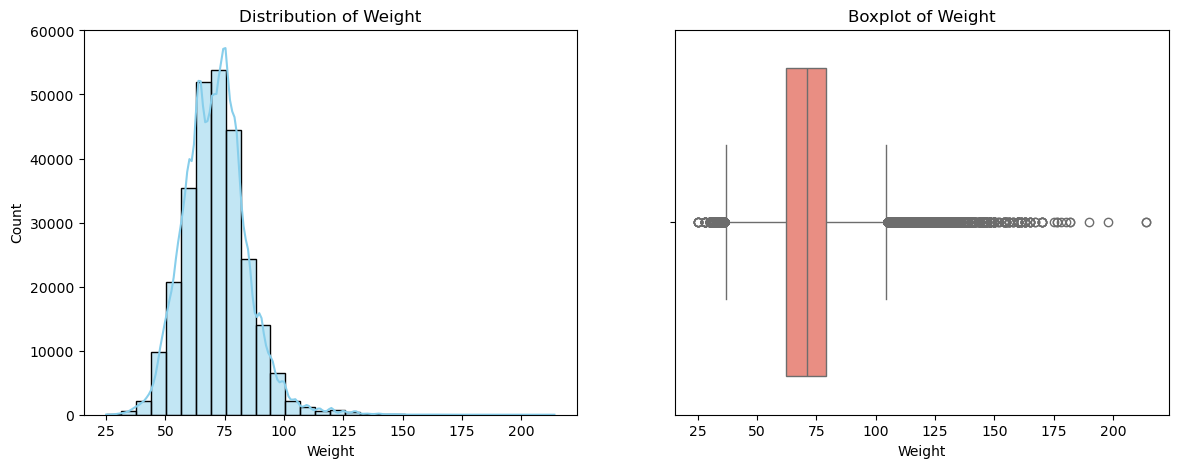

In [24]:
num_cols = ['Age', 'Height', 'Weight']

for col in num_cols:
    print("="*60)
    print(f"📊 Analysis for: {col}")
    print(merged_df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
    print("Skewness:", merged_df[col].skew())
    print("Kurtosis:", merged_df[col].kurt())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(merged_df[col], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=merged_df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.show()

📊 Analysis for: Sex
Sex
M    194965
F     74117
Name: count, dtype: int64
Unique categories: 2


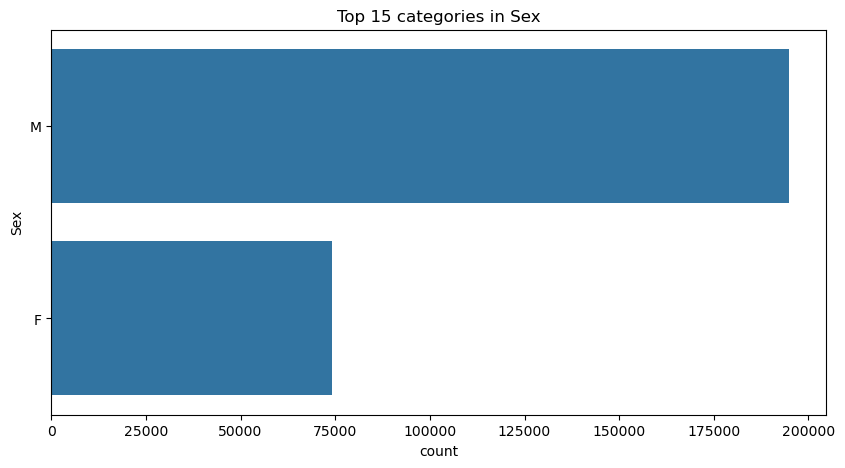

📊 Analysis for: Medal
Medal
NaN       229498
Gold       13292
Bronze     13237
Silver     13055
Name: count, dtype: int64
Unique categories: 3


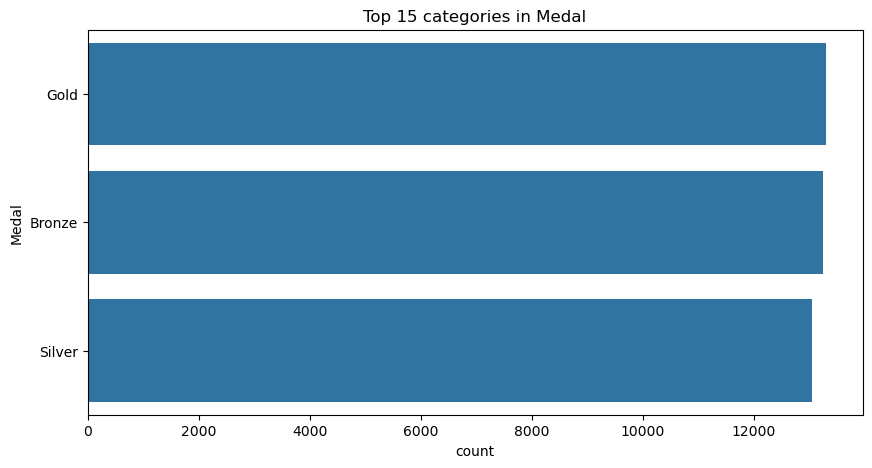

📊 Analysis for: Sport
Sport
Athletics               38624
Gymnastics              26663
Swimming                23195
Shooting                11433
Cycling                 10817
Fencing                 10735
Rowing                  10595
Cross Country Skiing     9132
Alpine Skiing            8829
Wrestling                7152
Football                 6734
Sailing                  6547
Equestrianism            6343
Canoeing                 6171
Boxing                   6045
Name: count, dtype: int64
Unique categories: 56


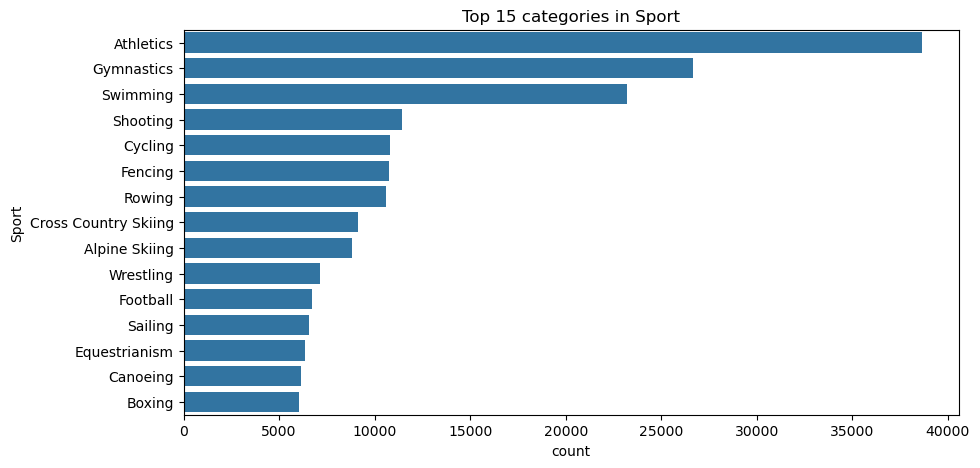

📊 Analysis for: Event
Event
Football Men's Football                   5722
Ice Hockey Men's Ice Hockey               4762
Hockey Men's Hockey                       3958
Water Polo Men's Water Polo               3356
Basketball Men's Basketball               3243
Cycling Men's Road Race, Individual       2941
Gymnastics Men's Individual All-Around    2494
Rowing Men's Coxed Eights                 2423
Gymnastics Men's Team All-Around          2405
Handball Men's Handball                   2264
Athletics Men's Marathon                  2093
Gymnastics Men's Parallel Bars            2043
Gymnastics Men's Horizontal Bar           2035
Gymnastics Men's Pommelled Horse          2026
Gymnastics Men's Rings                    2015
Name: count, dtype: int64
Unique categories: 752


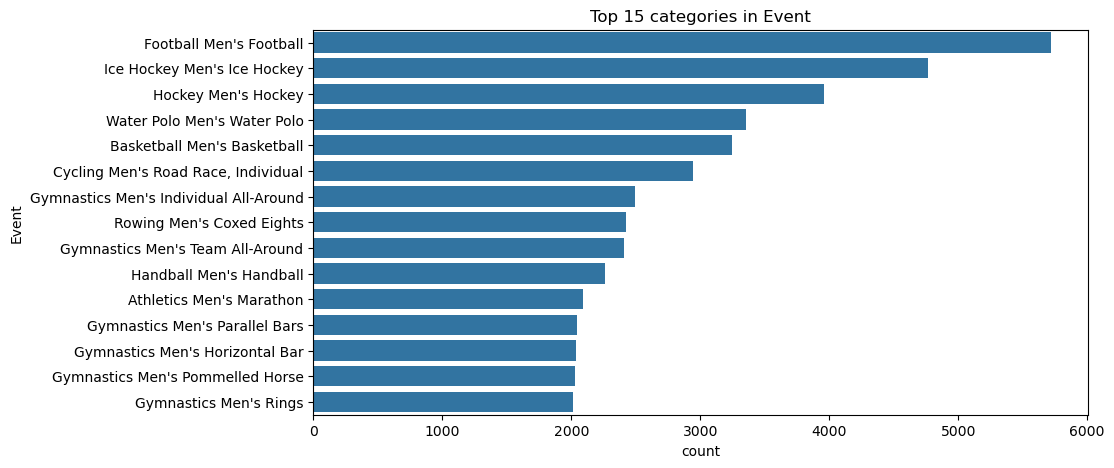

📊 Analysis for: Season
Season
Summer    220564
Winter     48518
Name: count, dtype: int64
Unique categories: 2


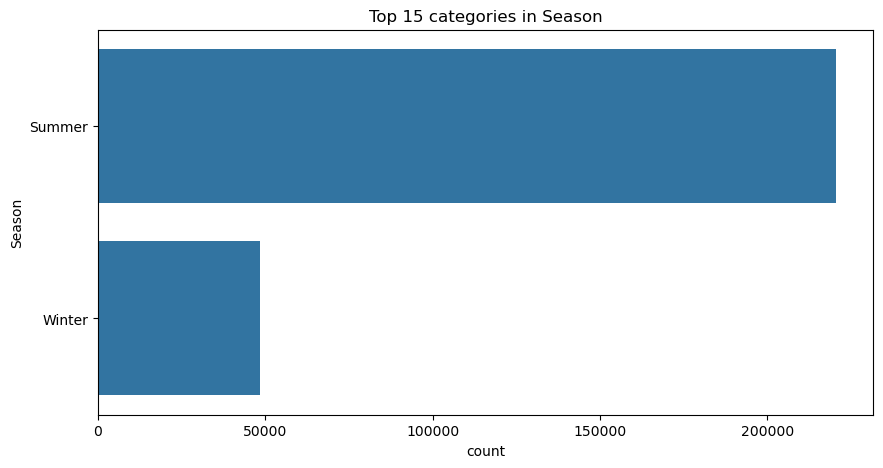

📊 Analysis for: region
region
USA               18533
Germany           15773
France            12489
UK                11994
Russia            11691
Italy             10658
Canada             9675
Japan              8419
Sweden             8288
Australia          7721
Hungary            6545
Czech Republic     6399
Poland             6132
Switzerland        6074
China              5825
Name: count, dtype: int64
Unique categories: 206


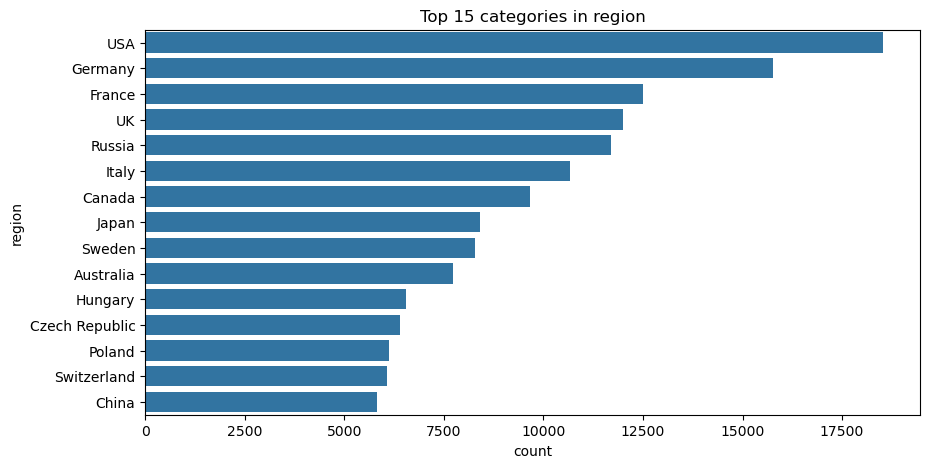

In [25]:
categorical_cols = ['Sex', 'Medal', 'Sport', 'Event', 'Season', 'region']

for col in categorical_cols:
    print("="*60)
    print(f"📊 Analysis for: {col}")
    print(merged_df[col].value_counts(dropna=False).head(15))  
    print("Unique categories:", merged_df[col].nunique())
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=merged_df, y=col, order=merged_df[col].value_counts().index[:15])
    plt.title(f"Top 15 categories in {col}")
    plt.show()


### Bivariate and Multi-variate Analysis

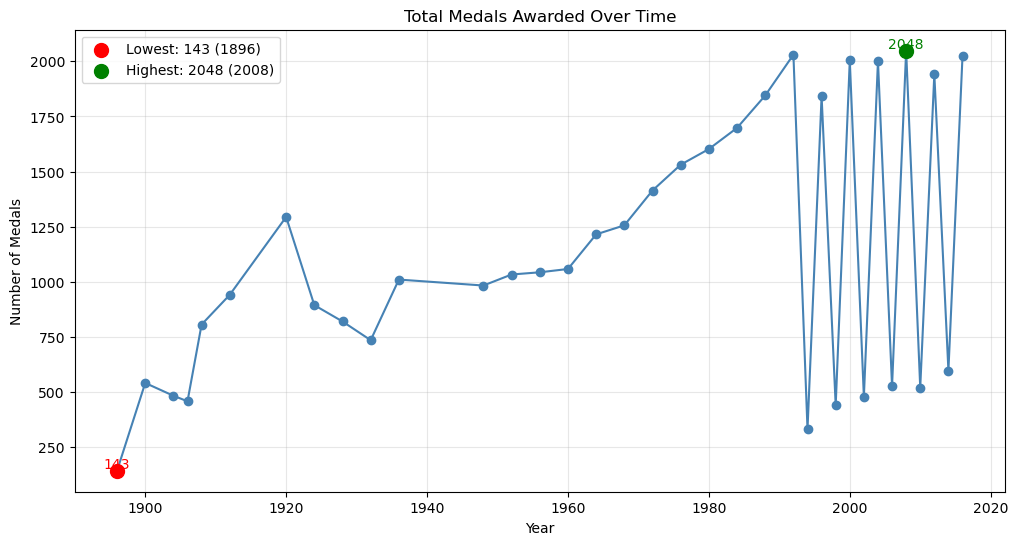

In [28]:
medals_over_time = merged_df.dropna(subset=['Medal']).groupby('Year')['Medal'].count()

min_year = medals_over_time.idxmin()
min_val = medals_over_time.min()
max_year = medals_over_time.idxmax()
max_val = medals_over_time.max()

plt.figure(figsize=(12,6))
plt.plot(medals_over_time.index, medals_over_time.values, marker='o', color='steelblue')

plt.scatter(min_year, min_val, color='red', s=100, zorder=5, label=f"Lowest: {min_val} ({min_year})")
plt.text(min_year, min_val+10, f"{min_val}", color='red', ha='center', fontsize=10)

plt.scatter(max_year, max_val, color='green', s=100, zorder=5, label=f"Highest: {max_val} ({max_year})")
plt.text(max_year, max_val+10, f"{max_val}", color='green', ha='center', fontsize=10)

plt.title("Total Medals Awarded Over Time")
plt.ylabel("Number of Medals")
plt.xlabel("Year")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [29]:
medals_df.head(10)

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3
5,6,Australia,17,7,22,46,6
6,7,Netherlands,10,12,14,36,9
7,8,France,10,12,11,33,10
8,9,Germany,10,11,16,37,8
9,10,Italy,10,10,20,40,7


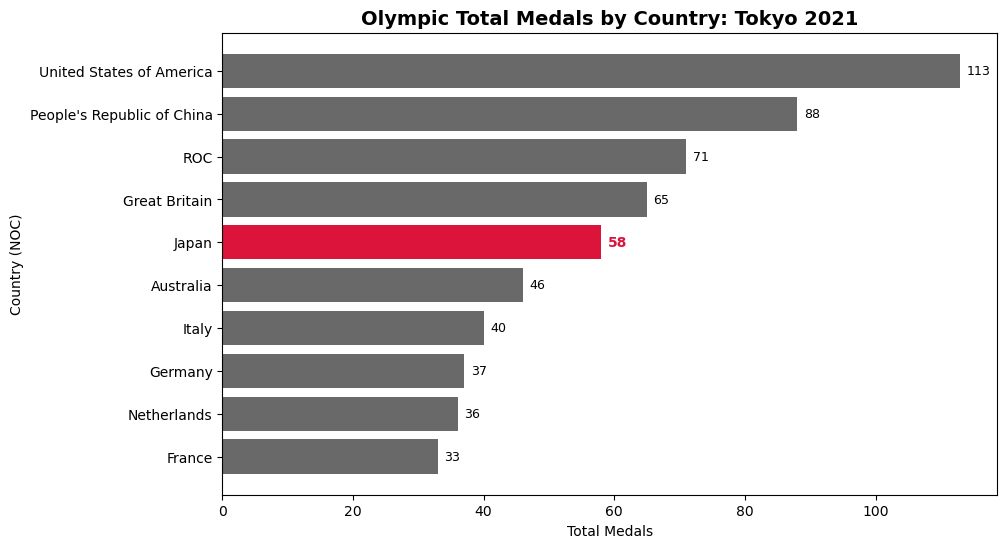

In [ ]:
medals_by_noc = medals_df.groupby('Team/NOC')[['Gold','Silver','Bronze','Total']].sum().reset_index()
medals_by_noc = medals_by_noc.sort_values('Total', ascending=False)

topN = medals_by_noc.head(10)

japan_label = "Japan" 
colors = ["crimson" if x == japan_label else "dimgray" for x in topN['Team/NOC']]

plt.figure(figsize=(10,6))
bars = plt.barh(topN['Team/NOC'], topN['Total'], color=colors)

for i, (country, total) in enumerate(zip(topN['Team/NOC'], topN['Total'])):
    if country == japan_label:
        plt.text(total + 1, i, str(total), va='center', fontsize=10, color='crimson', weight='bold')
    else:
        plt.text(total + 1, i, str(total), va='center', fontsize=9, color='black')

plt.title("Olympic Total Medals by Country: Tokyo 2021", fontsize=14, weight='bold')
plt.xlabel("Total Medals")
plt.ylabel("Country (NOC)")

plt.gca().invert_yaxis()
plt.show()

We see a familiar top position with United States of America, China, Great Britain and Japan

c:\Users\phunh.DESKTOP-8S8LTG6\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


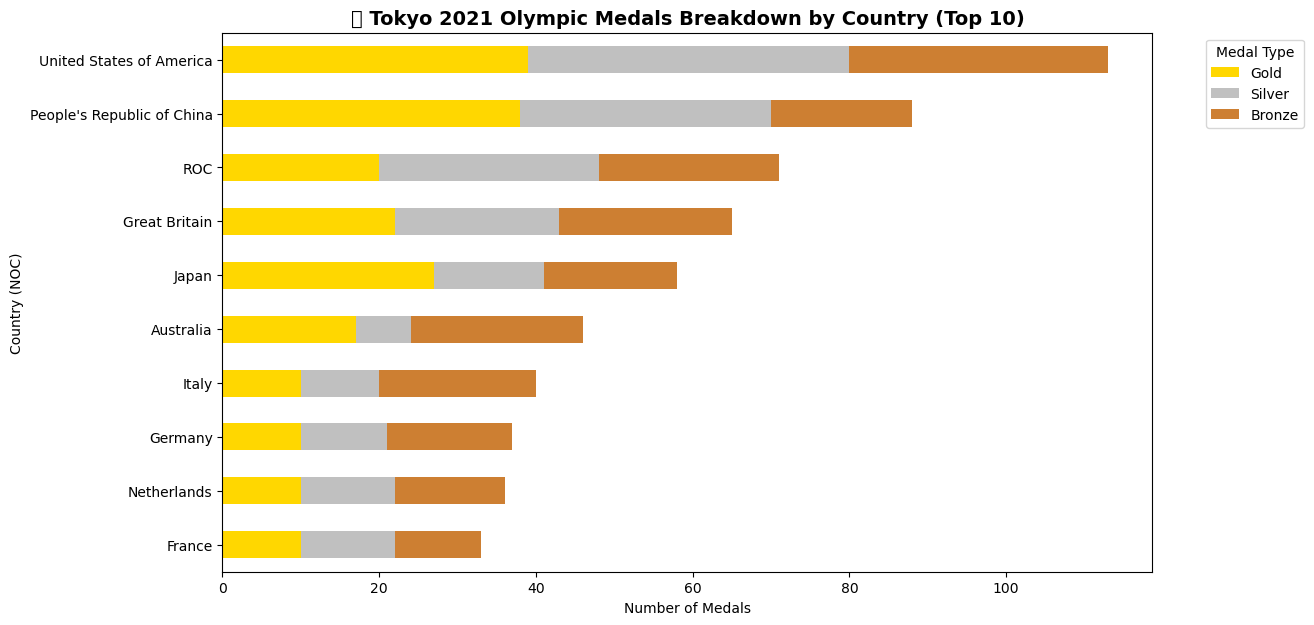

In [45]:
medals_by_noc = medals_df.groupby('Team/NOC')[['Gold','Silver','Bronze','Total']].sum().reset_index()
medals_by_noc = medals_by_noc.sort_values('Total', ascending=False)

top10 = medals_by_noc.head(10).set_index('Team/NOC')

top10[['Gold','Silver','Bronze']].plot(
    kind='barh',
    stacked=True,
    figsize=(12,7),
    color=['#FFD700', '#C0C0C0', '#CD7F32']  
)

plt.title("🏅 Tokyo 2021 Olympic Medals Breakdown by Country (Top 10)", fontsize=14, weight='bold')
plt.xlabel("Number of Medals")
plt.ylabel("Country (NOC)")
plt.legend(title="Medal Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis() 
plt.show()

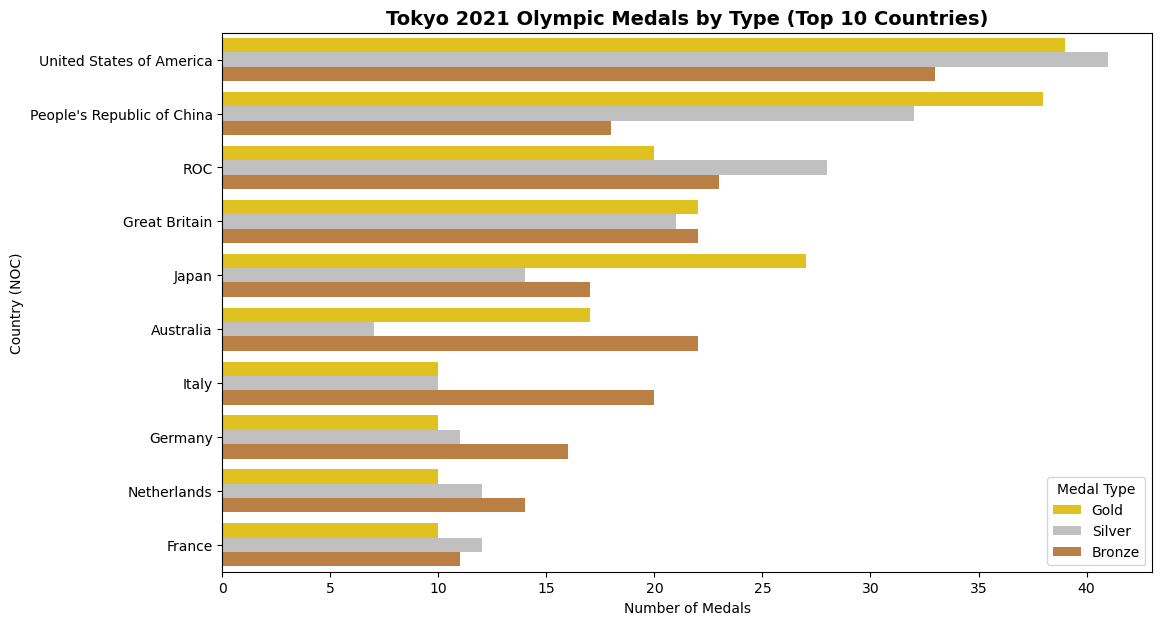

In [51]:
top10_long = top10[['Gold','Silver','Bronze']].reset_index().melt(id_vars='Team/NOC', var_name='Medal', value_name='Count')

plt.figure(figsize=(12,7))
sns.barplot(data=top10_long, x='Count', y='Team/NOC', hue='Medal',
            palette={'Gold':'#FFD700', 'Silver':'#C0C0C0', 'Bronze':'#CD7F32'})

plt.title("Tokyo 2021 Olympic Medals by Type (Top 10 Countries)", fontsize=14, weight='bold')
plt.xlabel("Number of Medals")
plt.ylabel("Country (NOC)")
plt.legend(title="Medal Type")
plt.show()